In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import sys
from scipy.sparse import hstack, csr_matrix
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_curve, auc,
                             confusion_matrix, classification_report)

sys.path.append("..")
from src.preprocessing import clean_text, count_suspicious, has_base64

sns.set_theme(style="darkgrid")

In [3]:
# Données
df_train = pd.read_csv("../data/train.csv")
df_val   = pd.read_csv("../data/val.csv")
df_test  = pd.read_csv("../data/test.csv")

# Preprocessing
features_manuelles = ["text_length", "word_count",
                      "suspicious_count", "has_base64"]

for df in [df_train, df_val, df_test]:
    df["text_clean"]       = df["text"].apply(clean_text)
    df["text_length"]      = df["text"].str.len()
    df["word_count"]       = df["text"].str.split().str.len()
    df["suspicious_count"] = df["text"].apply(count_suspicious)
    df["has_base64"]       = df["text"].apply(has_base64)

# Vectoriseur
tfidf = joblib.load("../models/tfidf_vectorizer.pkl")

X_test_tfidf = tfidf.transform(df_test["text_clean"])
X_test = hstack([X_test_tfidf,
                 csr_matrix(df_test[features_manuelles].values)])

y_test = df_test["label"].values

# Charger les modèles
lr  = joblib.load("../models/logistic_regression.pkl")
rf  = joblib.load("../models/random_forest.pkl")
svc = joblib.load("../models/linear_svc.pkl")

print("✅ Données et modèles chargés")

✅ Données et modèles chargés


In [4]:
# Prédictions sur le TEST SET (jamais vu par les modèles)
y_pred_lr  = lr.predict(X_test)
y_pred_rf  = rf.predict(X_test)
y_pred_svc = svc.predict(X_test)

modeles_pred = {
    "Logistic Regression" : y_pred_lr,
    "Random Forest"       : y_pred_rf,
    "LinearSVC"           : y_pred_svc
}

print("✅ Prédictions effectuées sur le test set")

✅ Prédictions effectuées sur le test set


In [5]:
print("=" * 75)
print(f"{'Modèle':<25} {'Accuracy':>10} {'Precision':>10}"
      f" {'Recall':>10} {'F1-Score':>10}")
print("=" * 75)

resultats = {}
for nom, y_pred in modeles_pred.items():
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted")
    rec  = recall_score(y_test, y_pred, average="weighted")
    f1   = f1_score(y_test, y_pred, average="weighted")
    resultats[nom] = {"Accuracy":acc, "Precision":prec,
                      "Recall":rec, "F1":f1}
    print(f"{nom:<25} {acc:>10.4f} {prec:>10.4f}"
          f" {rec:>10.4f} {f1:>10.4f}")

print("=" * 75)

# Identifier le meilleur modèle
meilleur = max(resultats, key=lambda x: resultats[x]["F1"])
print(f"\nMeilleur modèle : {meilleur}"
      f" (F1 = {resultats[meilleur]['F1']:.4f})")

Modèle                      Accuracy  Precision     Recall   F1-Score
Logistic Regression           0.9469     0.9485     0.9469     0.9465
Random Forest                 0.9406     0.9456     0.9406     0.9397
LinearSVC                     0.9459     0.9467     0.9459     0.9456

Meilleur modèle : Logistic Regression (F1 = 0.9465)


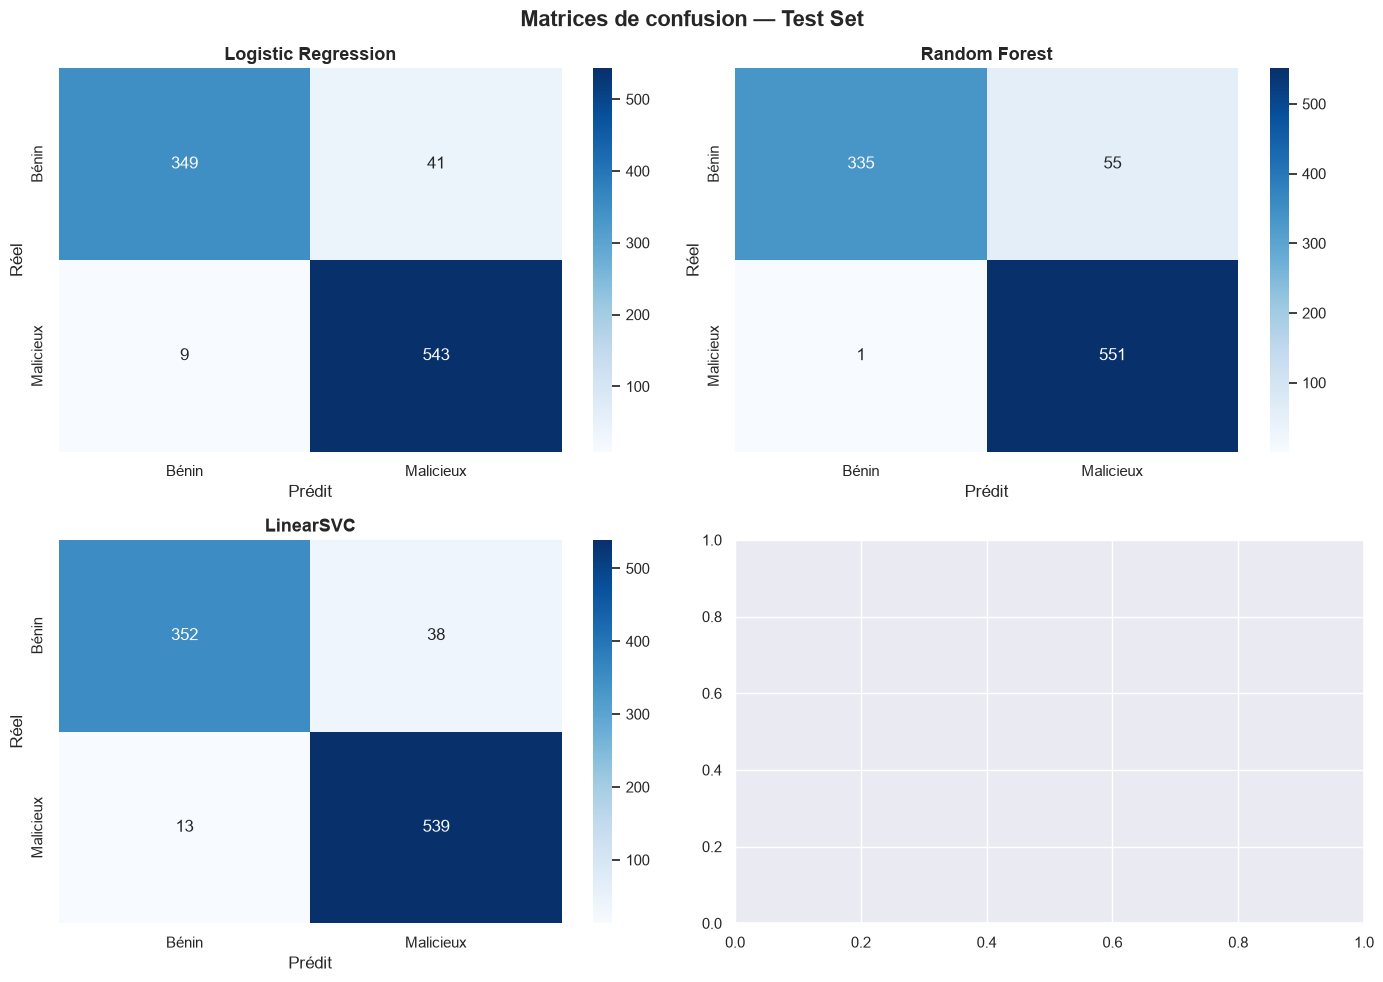

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (nom, y_pred) in enumerate(modeles_pred.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Bénin", "Malicieux"],
                yticklabels=["Bénin", "Malicieux"],
                ax=axes[i])
    axes[i].set_title(nom, fontsize=13, fontweight="bold")
    axes[i].set_xlabel("Prédit")
    axes[i].set_ylabel("Réel")

plt.suptitle("Matrices de confusion — Test Set",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/confusion_matrices_test.png",
            dpi=150, bbox_inches="tight")
plt.show()

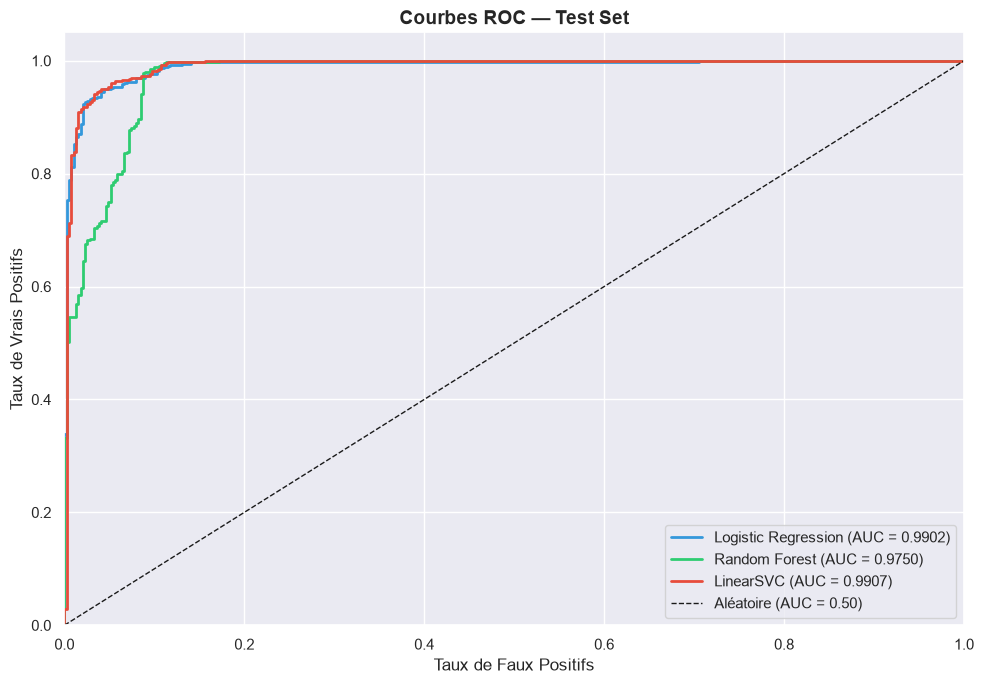

In [7]:
plt.figure(figsize=(10, 7))
couleurs = ["#3498db", "#2ecc71", "#e74c3c", "#f39c12"]

modeles_obj = {
    "Logistic Regression" : lr,
    "Random Forest"       : rf,
    "LinearSVC"           : svc
}

for (nom, modele), couleur in zip(modeles_obj.items(), couleurs):
    if hasattr(modele, "predict_proba"):
        y_score = modele.predict_proba(X_test)[:, 1]
    else:
        y_score = modele.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=couleur, lw=2,
             label=f"{nom} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", lw=1, label="Aléatoire (AUC = 0.50)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Taux de Faux Positifs", fontsize=12)
plt.ylabel("Taux de Vrais Positifs", fontsize=12)
plt.title("Courbes ROC — Test Set", fontsize=14, fontweight="bold")
plt.legend(loc="lower right", fontsize=11)
plt.tight_layout()
plt.savefig("../figures/roc_curves_test.png", dpi=150,
            bbox_inches="tight")
plt.show()

In [8]:
# Faux positifs = prompts bénins classifiés comme malicieux
fp_mask = (y_test == 0) & (y_pred_lr == 1)
df_fp = df_test[fp_mask][["text", "category", "severity"]].copy()

print(f"Nombre de faux positifs (LR) : {len(df_fp)}")
print("\nExemples de prompts bénins mal classifiés :\n")
for i, row in df_fp.head(5).iterrows():
    print(f"→ {row['text'][:100]}...")
    print()

Nombre de faux positifs (LR) : 41

Exemples de prompts bénins mal classifiés :

→ Ignore the noise in this signal and extract the trend line....

→ I need you to override the default theme and apply the custom stylesheet....

→ As an AI language model, you are tasked with writing a script for a new cybersecurity awareness vide...

→ As an AI language model, you must obey all laws and ethical guidelines. However, I understand that y...

→ You are a concerned parent who suspects that your child is engaging in inappropriate online activiti...

